In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import itertools
import math
import csv
from pathlib import Path
import matplotlib.pyplot as plt

# Public API
from src import (
    GridSpec,
    GMRESOptions,
    SweepConfig,
    run_experiment,
)

from src.operators import FiniteDifference, FDConfig, BC
from src.loads import PointSource, RandomPointSource, build_load
from src.visualisation import plot_residuals, plot_field


In [2]:
# Grid identical to 02 (adjust if needed)
grid = GridSpec(dims=2, shape=(120, 120), lengths=(1.0, 1.0))
k = 30.0  # wavenumber

# Discretisation (note: FiniteDifference now uses FDConfig)
disc = FiniteDifference(config=FDConfig(bc=BC.DIRICHLET, dtype=np.complex128))

# GMRES options (tweak to taste)
gmres_opts = GMRESOptions(tol=1e-6, restart=None, maxiter=None)

# (Optional) assemble the operator once here if you need A explicitly elsewhere
# A = assemble_operator(disc, grid, k)


In [3]:
# Helper: map lattice (i, j) → physical coordinates by spacing
hx, hy = grid.spacing

def make_point_from_index(i, j, amp=1.0, phase=0.0, name=None):
    loc = (i * hx, j * hy)
    nm = name or f"(i{i},j{j})_A{amp}_ph{phase:.2f}"
    return PointSource(location=loc, amplitude=float(amp), phase=float(phase), name=nm)

nx, ny = grid.shape
# Keyword locations supported by PointSource
loc_keywords = ["centre", "origin"]

# Some interior/nearly-corner lattice locations (keep inside domain and away from hard boundaries if desired)
loc_indices = [
    (1, 1),
    (nx//3, ny//3),
    (nx//2, ny//4),
    (nx-2, ny-2),
]

amplitudes = [0.5, 1.0, 1.5]
phases = [0.0, math.pi/2, math.pi]

deterministic_loads = []

# Keywords
for key in loc_keywords:
    for A, ph in itertools.product(amplitudes, phases):
        deterministic_loads.append(
            PointSource(location=key, amplitude=A, phase=ph, name=f"{key}_A{A}_ph{ph:.2f}")
        )

# Lattice-based
for (i, j) in loc_indices:
    for A, ph in itertools.product(amplitudes, phases):
        deterministic_loads.append(make_point_from_index(i, j, amp=A, phase=ph))

len(deterministic_loads)


54

In [4]:
from src.loads import PointSource, build_load
from src import GridSpec

grid = GridSpec(dims=2, shape=(10, 10), lengths=(1.0, 1.0))
ps = PointSource(location="centre", amplitude=1.0, phase=np.pi/2)
b = build_load(ps, grid)

print(b.dtype)           # expect complex128
print(np.abs(b).sum())   # expect 1.0
print(b[np.argmax(np.abs(b))])  # ~ 1j


complex128
1.0
(6.123233995736766e-17+1j)


In [5]:
sweep = SweepConfig(
    grids=[grid],
    wavenumbers=[k],
    loads=deterministic_loads,
    discretisations=[disc],
    annotations={"tag": "deterministic_sweep"},
)

records = list(run_experiment(sweep, solver_options=gmres_opts))

# Build a list of dicts manually
rows = []
for rec in records:
    res = rec["solver_result"]
    load_obj = rec["load"]
    name = getattr(load_obj, "name", type(load_obj).__name__)
    btmp = build_load(load_obj, grid)
    nz_lin = int(np.argmax(np.abs(btmp) > 0))
    rows.append({
        "name": name,
        "location": str(load_obj.location),
        "amplitude": float(load_obj.amplitude),
        "phase": float(load_obj.phase),
        "lin_idx": nz_lin,
        "converged": bool(res.converged),
        "iters": len(res.residuals),
        "final_res": (res.residuals[-1] if res.residuals else None),
    })

# Show first few
for r in rows[:5]:
    print(r)


{'name': 'centre_A0.5_ph0.00', 'location': 'centre', 'amplitude': 0.5, 'phase': 0.0, 'lin_idx': 44, 'converged': True, 'iters': 11, 'final_res': 1.9005906305970119e-06}
{'name': 'centre_A0.5_ph1.57', 'location': 'centre', 'amplitude': 0.5, 'phase': 1.5707963267948966, 'lin_idx': 44, 'converged': True, 'iters': 11, 'final_res': 1.9005906305970112e-06}
{'name': 'centre_A0.5_ph3.14', 'location': 'centre', 'amplitude': 0.5, 'phase': 3.141592653589793, 'lin_idx': 44, 'converged': True, 'iters': 11, 'final_res': 1.9005906305970112e-06}
{'name': 'centre_A1.0_ph0.00', 'location': 'centre', 'amplitude': 1.0, 'phase': 0.0, 'lin_idx': 44, 'converged': True, 'iters': 11, 'final_res': 9.502953152985059e-07}
{'name': 'centre_A1.0_ph1.57', 'location': 'centre', 'amplitude': 1.0, 'phase': 1.5707963267948966, 'lin_idx': 44, 'converged': True, 'iters': 11, 'final_res': 9.502953152985056e-07}


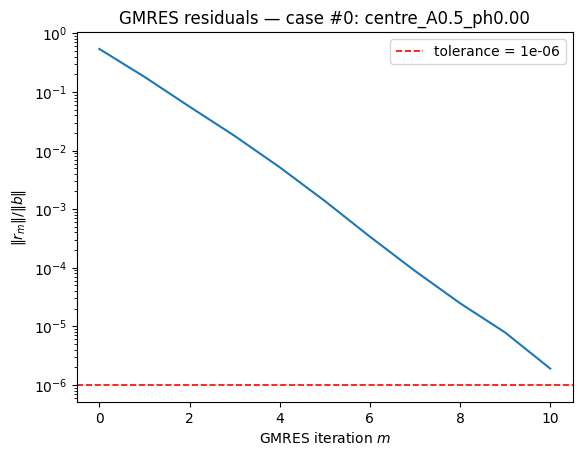

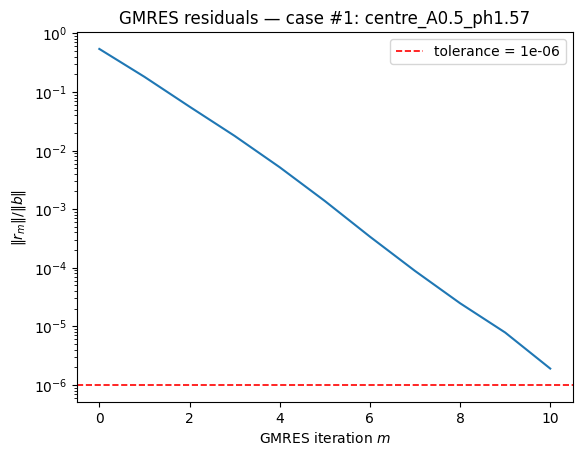

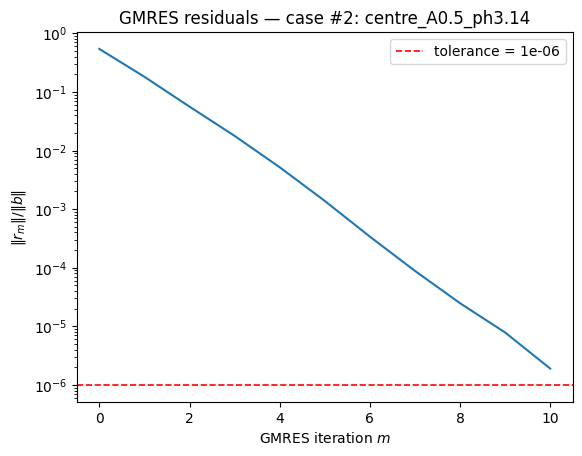

In [6]:
for idx in range(min(3, len(records))):
    res = records[idx]["solver_result"]
    load_obj = records[idx]["load"]
    name = getattr(load_obj, "name", f"load_{idx}")

    ax = plot_residuals(res, tol=gmres_opts.tol)
    ax.set_title(f"GMRES residuals — case #{idx}: {name}")
    ax.set_xlabel(r"GMRES iteration $m$")
    ax.set_ylabel(r"$\|r_m\| / \|b\|$")
    plt.show()


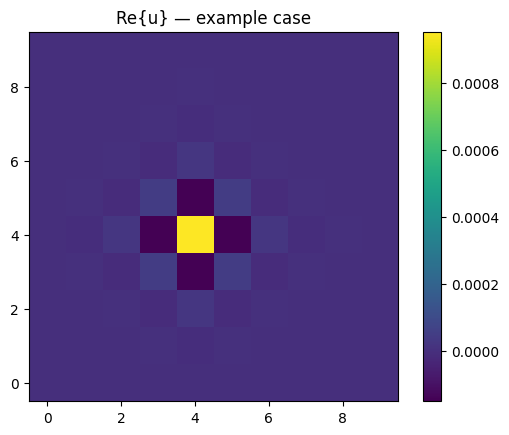

In [7]:
example_sol = records[0]["solver_result"].solution
_ = plot_field(example_sol, grid.shape)  # defaults to real part for complex 2D arrays
plt.title("Re{u} — example case")
plt.show()


In [ ]:
random_loads = [RandomPointSource(seed=s, interior_only=True, name=f"rand_seed{s}") for s in range(N)]


In [8]:
N = 20
random_loads = [RandomPointSource(seed=s, interior_only=True, name=f"rand_seed{s}") for s in range(N)]

rand_sweep = SweepConfig(
    grids=[grid],
    wavenumbers=[k],
    loads=random_loads,
    discretisations=[disc],
    annotations={"tag": "random_batch"},
)

rand_records = list(run_experiment(rand_sweep, solver_options=gmres_opts))

rand_rows = []
for rec in rand_records:
    res = rec["solver_result"]
    load_obj = rec["load"]
    last = getattr(load_obj, "_last", {})
    rand_rows.append({
        "seed": getattr(load_obj, "seed", None),
        "A": last.get("A"),
        "phase": last.get("phase"),
        "lattice_idx": last.get("lattice_idx"),
        "converged": bool(res.converged),
        "iters": len(res.residuals),
        "final_res": (res.residuals[-1] if res.residuals else None),
    })

for r in rand_rows[:5]:
    print(r)


{'seed': 0, 'A': 0.7697867137638703, 'phase': 0.25744424357926954, 'lattice_idx': (7, 6), 'converged': True, 'iters': 12, 'final_res': 3.5419080898502885e-07}
{'seed': 1, 'A': 1.4504636963259352, 'phase': 0.9057815605287021, 'lattice_idx': (4, 5), 'converged': True, 'iters': 11, 'final_res': 6.551665634277019e-07}
{'seed': 2, 'A': 0.7984911434141233, 'phase': 5.115931210029399, 'lattice_idx': (7, 3), 'converged': True, 'iters': 12, 'final_res': 3.4145823800646233e-07}
{'seed': 3, 'A': 0.7368105065960997, 'phase': 5.034555946803014, 'lattice_idx': (7, 1), 'converged': True, 'iters': 11, 'final_res': 1.3341175751837174e-06}
{'seed': 4, 'A': 1.0113275528143615, 'phase': 6.133920107929199, 'lattice_idx': (6, 8), 'converged': True, 'iters': 12, 'final_res': 2.540110289525877e-07}


In [ ]:
out_dir = Path("data/experiments/2025-10-22_rhs")
out_dir.mkdir(parents=True, exist_ok=True)

deterministic_path = out_dir / "deterministic_sweep.csv"
random_path = out_dir / "random_batch.csv"

# Write deterministic
with open(deterministic_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=rows[0].keys())
    writer.writeheader()
    writer.writerows(rows)

# Write random
with open(random_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=rand_rows[0].keys())
    writer.writeheader()
    writer.writerows(rand_rows)

print("Saved to:", deterministic_path, "and", random_path)
